# 03_Preprocessing

Raw EEG signals contain noise from many sources that must be removed before analysis:

| Artifact | Source | Removal |
|----------|--------|---------|
| Slow drifts | Sweat, electrode movement | High-pass filter |
| Muscle noise | EMG | Low-pass filter |
| Power line | Electrical interference | Notch filter (60 Hz) |
| Eye blinks / movements | EOG | ICA |
| Bad channels | Loose/broken electrode | Detect → interpolate |
| Noisy epochs | Movement, coughing | Amplitude rejection |

## 0. Pipeline
```
Load raw .bdf
  → Set montage + reclassify EXG as EOG
  → Bandpass filter (1–40 Hz) + Notch (60 Hz)
  → Detect & interpolate bad channels  (pyprep, before re-referencing)
  → Average re-reference
  → ICA — remove eye blink components
  → Epoch into 2-second segments (EEG channels only)
  → Reject high-amplitude epochs (>150 µV)
  → Save  →  processed/sub-{id}_ses-{ses}-epo.fif
```

**Dataset channels:** 32 EEG (10-20 system) + 8 EXG (BioSemi external = EOG) + 1 trigger  
**Sampling rate:** 512 Hz  
**Recording length:** ~192 s per session

In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals
from mne.preprocessing import ICA
from pyprep.find_noisy_channels import NoisyChannels

mne.set_log_level('WARNING')
warnings.filterwarnings('ignore', message='Unable to map the following column', category=RuntimeWarning)

BIDS_ROOT  = os.path.join('datasets', 'ds002778')
SAVE_DIR   = 'processed'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Preprocessing parameters ──────────────────────────────────────────────
L_FREQ      = 1.0    # high-pass Hz — removes slow drifts
H_FREQ      = 40.0   # low-pass Hz  — removes muscle noise
NOTCH_FREQ  = 60.0   # power line (60 Hz North America)
EPOCH_LEN   = 2.0    # seconds per epoch
AMP_THRESH  = 150e-6 # rejection threshold (150 µV) — 99th pct is ~121 µV
N_ICA_COMP  = 20     # ICA components to fit

print('Setup complete.')
print(f'  Bandpass  : {L_FREQ}–{H_FREQ} Hz')
print(f'  Notch     : {NOTCH_FREQ} Hz')
print(f'  Epoch len : {EPOCH_LEN} s')
print(f'  AMP thresh: {AMP_THRESH*1e6:.0f} µV')

Setup complete.
  Bandpass  : 1.0–40.0 Hz
  Notch     : 60.0 Hz
  Epoch len : 2.0 s
  AMP thresh: 150 µV


## Step 1: Load & Inspect One Subject

We first run the full pipeline on a single subject to verify each step before processing all subjects.

In [16]:
subjects = get_entity_vals(BIDS_ROOT, 'subject')
hc_subs  = [s for s in subjects if 'hc' in s.lower()]
pd_subs  = [s for s in subjects if 'pd' in s.lower()]

sub, ses = hc_subs[0], 'hc'
print(f'Loading sub-{sub} ses-{ses}...')

bp  = BIDSPath(subject=sub, session=ses, task='rest', datatype='eeg', root=BIDS_ROOT)
raw = read_raw_bids(bp, verbose=False).load_data()

print(f'Channels      : {len(raw.ch_names)}')
print(f'Sampling rate : {raw.info["sfreq"]} Hz')
print(f'Duration      : {raw.times[-1]:.1f} s')

Loading sub-hc1 ses-hc...
Channels      : 41
Sampling rate : 512.0 Hz
Duration      : 192.0 s


## Step 2: Set Montage & Reclassify EXG Channels

**Montage** assigns 3D electrode positions to channel names.  
Required for: pyprep bad channel detection, topomaps, source localization.

**EXG channels** are BioSemi external electrodes — in this dataset they capture eye movements (EOG).  
Reclassifying them lets MNE use them automatically during ICA artifact detection.

In [17]:
# Set standard 10-20 montage (matches EEG channel names)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')

# Reclassify EXG channels as EOG
exg_chs = [c for c in raw.ch_names if c.startswith('EXG')]
raw.set_channel_types({ch: 'eog' for ch in exg_chs})

# Branch ICA copy HERE — before the bandpass filter is applied.
# ICA needs access to the full artefact bandwidth; branching after bandpass
# would limit ICA to 1-40 Hz and degrade blink/saccade component separation.
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

print(f'Montage set  : {len([d for d in raw.info["dig"] if d["kind"]==3])} electrode positions')
print(f'EOG channels : {exg_chs}')
print(f'ICA copy ready (1 Hz high-pass, pre-bandpass)')

Montage set  : 32 electrode positions
EOG channels : ['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
ICA copy ready (1 Hz high-pass, pre-bandpass)


## Step 3: Filtering

**Bandpass (1–40 Hz):**  
- 1 Hz high-pass removes slow baseline drifts (sweat, DC offset)  
- 40 Hz low-pass removes high-frequency muscle (EMG) artifacts  

**Notch (60 Hz):**  
- Removes AC power line interference (60 Hz in North America)

C:\Users\User\AppData\Local\Temp\ipykernel_10720\4267237083.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


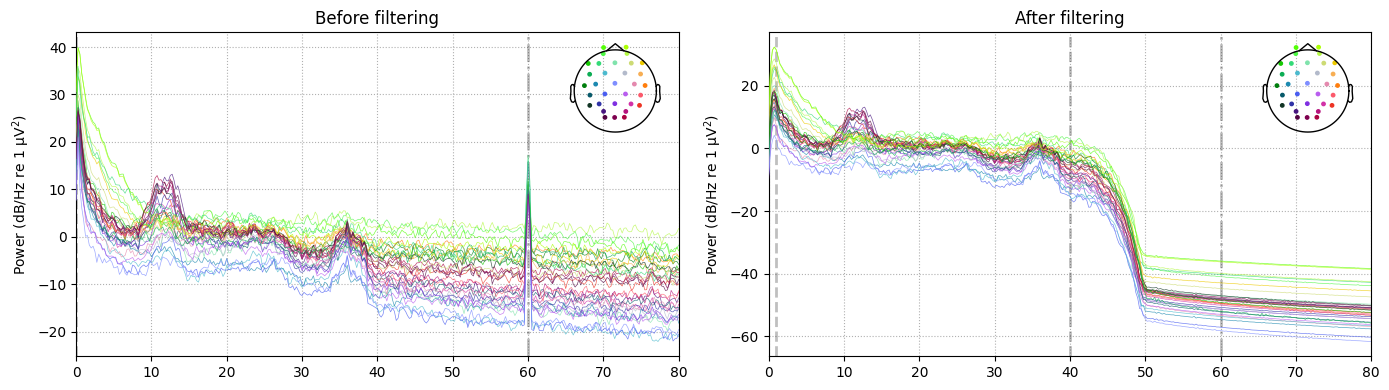

Filtering done.


In [18]:
raw_prefilt = raw.copy()  # keep for before/after comparison

# Notch FIRST — eliminate 60 Hz line noise before bandpass.
# Applying notch after a 40 Hz low-pass would make it a no-op (60 Hz already gone).
raw.notch_filter(freqs=NOTCH_FREQ)
raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, method='fir', fir_window='hamming')

# Compare PSD before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_prefilt.compute_psd(fmax=80, picks='eeg').plot(axes=axes[0], show=False)
axes[0].set_title('Before filtering')
raw.compute_psd(fmax=80, picks='eeg').plot(axes=axes[1], show=False)
axes[1].set_title('After filtering')
plt.tight_layout()
plt.show()
print('Filtering done.')

## Step 4: Bad Channel Detection & Interpolation

Using **pyprep** (Python implementation of the PREP pipeline — standard in EEG research).  
Run *before* average re-referencing — the PREP pipeline requires this order.

Bad channels are reconstructed via **spherical spline interpolation** from neighbouring electrodes.

In [19]:
try:
    # NoisyChannels expects a pure-EEG input — passing mixed EEG+EOG corrupts
    # the correlation/RANSAC statistics. Use a picks-restricted copy.
    nd = NoisyChannels(raw.copy().pick('eeg'), random_state=42)
    nd.find_all_bads()
    bads = nd.get_bads()
    print(f'Bad channels detected: {bads if bads else "none"} ({len(bads)})')
    if bads:
        raw.info['bads'] = bads
        raw.interpolate_bads(reset_bads=True)
        print('Interpolation done.')
except Exception as e:
    print(f'pyprep skipped: {e}')

Bad channels detected: ['AF4', 'C3', 'Cz', 'F3', 'AF3'] (5)
Interpolation done.


## Step 5: Average Re-referencing

EEG voltages are relative to a reference electrode. **Average reference** is standard for resting-state:  
subtracts the mean of all electrodes at each time point, making the data reference-independent.  

> Note: done *after* bad channel interpolation to avoid bad channels contaminating the average.

In [20]:
raw.set_eeg_reference('average', projection=True)
raw.apply_proj()
print('Average reference applied.')

Average reference applied.


## Step 6: ICA (Independent Component Analysis)

ICA separates the EEG signal into statistically independent components.  
Eye blinks and saccades produce large, spatially stable components that can be automatically identified  
by correlating ICA sources with the EOG channels (EXG1–EXG8).

`raw_for_ica` was branched in Step 2 **before** the bandpass filter — this matters because:
- Artefacts (blinks, saccades) have energy across the full spectrum, not just 1–40 Hz
- Fitting ICA on pre-bandpass data gives the algorithm the broadest signal representation, improving component separation
- The ICA solution (component weights) is then applied to the properly filtered `raw`

In [21]:
# raw_for_ica was created in Step 2 (pre-bandpass) — use it directly here.
ica = ICA(n_components=N_ICA_COMP, random_state=42, method='fastica')
ica.fit(raw_for_ica, picks='eeg')

# Use mne.pick_types — canonical, version-stable alternative to mne.channel_type()
eog_chs = [raw.ch_names[i] for i in mne.pick_types(raw.info, eog=True)]
eog_indices = []
for eog_ch in eog_chs[:2]:  # first 2 EXG channels capture blink + saccade
    found, _ = ica.find_bads_eog(raw, ch_name=eog_ch)
    eog_indices.extend(found)
eog_indices = list(set(eog_indices))

print(f'EOG artifact components: {eog_indices}')

# Visualise the identified components
if eog_indices:
    ica.plot_components(picks=eog_indices, title='Components to remove')
    plt.show()

EOG artifact components: []


In [22]:
# Apply — remove EOG components from the signal
ica.exclude = eog_indices
ica.apply(raw)
print(f'Removed {len(ica.exclude)} component(s). Signal cleaned.')

Removed 0 component(s). Signal cleaned.


## Step 7: Epoching

Resting-state has no stimulus events, so we use **fixed-length epochs** (sliding window).  

- **2 seconds** per epoch: enough for reliable band power estimates (≥5 cycles at 2.5 Hz)  
- **No overlap**: keeps epochs independent for cross-validation  
- **EEG channels only**: EOG channels dropped before saving

In [23]:
# Pick EEG only before epoching
raw_eeg = raw.copy().pick('eeg')

epochs = mne.make_fixed_length_epochs(
    raw_eeg,
    duration=EPOCH_LEN,
    overlap=0.0,
    preload=True
)
print(f'Epochs created: {len(epochs)}')

Epochs created: 96


## Step 8: Epoch Rejection

Reject any remaining epochs where a channel exceeds **150 µV**.  
(99th percentile of this dataset is ~121 µV, so 150 µV is conservative.)

In [24]:
epochs.drop_bad(reject={'eeg': AMP_THRESH})

n_kept = len(epochs)
print(f'Epochs kept    : {n_kept}')
print(f'Duration kept  : {n_kept * EPOCH_LEN:.1f} s  ({n_kept * EPOCH_LEN / 60:.1f} min)')

Epochs kept    : 55
Duration kept  : 110.0 s  (1.8 min)


## Step 9: Save

Save cleaned epochs as MNE `.fif` format into `processed/`.  
This directory is in `.gitignore` and will not be committed.

In [25]:
save_path = os.path.join(SAVE_DIR, f'sub-{sub}_ses-{ses}-epo.fif')
epochs.save(save_path, overwrite=True)
print(f'Saved: {save_path}')

Saved: processed\sub-hc1_ses-hc-epo.fif


## Step 10: Run Full Pipeline on All Subjects

Process all 31 subjects across all sessions:

| Group | Session | n subjects |
|-------|---------|------------|
| HC | `ses-hc` | 16 |
| PD | `ses-off` | 15 |
| PD | `ses-on` | 15 |

In [26]:
def preprocess_subject(sub, ses):
    """Full preprocessing pipeline for one subject/session.
    Returns cleaned Epochs, or None on failure.
    Skips if output file already exists.
    """
    save_path = os.path.join(SAVE_DIR, f'sub-{sub}_ses-{ses}-epo.fif')
    if os.path.exists(save_path):
        print(f'  sub-{sub} ses-{ses}: already exists, skipping')
        return mne.read_epochs(save_path, verbose=False)

    try:
        # 1. Load
        bp  = BIDSPath(subject=sub, session=ses, task='rest', datatype='eeg', root=BIDS_ROOT)
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=RuntimeWarning)
            raw = read_raw_bids(bp, verbose=False).load_data()

        # 2. Montage + channel types
        raw.set_montage(mne.channels.make_standard_montage('standard_1020'), on_missing='ignore')
        exg = [c for c in raw.ch_names if c.startswith('EXG')]
        raw.set_channel_types({c: 'eog' for c in exg})

        # Branch ICA copy BEFORE bandpass
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

        # 3. Filter — notch first, then bandpass
        raw.notch_filter(freqs=NOTCH_FREQ, verbose=False)
        raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, method='fir', fir_window='hamming', verbose=False)

        # 4. Bad channels (before re-reference) — EEG-only copy for pyprep
        try:
            nd = NoisyChannels(raw.copy().pick('eeg'), random_state=42)
            nd.find_all_bads()
            bads = nd.get_bads()
            if bads:
                raw.info['bads'] = bads
                raw.interpolate_bads(reset_bads=True)
        except Exception:
            pass

        # 5. Re-reference
        raw.set_eeg_reference('average', projection=True)
        raw.apply_proj()

        # 6. ICA — fit on pre-bandpass copy, apply to filtered raw
        ica = ICA(n_components=N_ICA_COMP, random_state=42, method='fastica')
        ica.fit(raw_for_ica, picks='eeg')
        eog_chs = [raw.ch_names[i] for i in mne.pick_types(raw.info, eog=True)]
        idx = []
        for eog_ch in eog_chs[:2]:
            found, _ = ica.find_bads_eog(raw, ch_name=eog_ch)
            idx.extend(found)
        ica.exclude = list(set(idx))
        ica.apply(raw)

        # 7. Epoch (EEG only)
        raw_eeg = raw.copy().pick('eeg')
        epochs  = mne.make_fixed_length_epochs(raw_eeg, duration=EPOCH_LEN, overlap=0.0, preload=True)

        # 8. Reject
        epochs.drop_bad(reject={'eeg': AMP_THRESH})

        # 9. Save
        if len(epochs) == 0:
            print(f'  sub-{sub} ses-{ses}: WARNING — 0 epochs remain, skipping save')
            return None
        epochs.save(save_path, overwrite=True)
        print(f'  sub-{sub} ses-{ses}: {len(epochs)} epochs -> {save_path}')
        return epochs

    except Exception as e:
        print(f'  sub-{sub} ses-{ses}: FAILED — {e}')
        return None

In [27]:
to_process = (
    [(s, 'hc')  for s in hc_subs] +
    [(s, 'off') for s in pd_subs] +
    [(s, 'on')  for s in pd_subs]
)

print(f'Processing {len(to_process)} subject-sessions...\n')
results = {}
for sub, ses in to_process:
    results[(sub, ses)] = preprocess_subject(sub, ses)

succeeded = sum(1 for v in results.values() if v is not None)
print(f'\nDone: {succeeded}/{len(to_process)} succeeded.')

Processing 46 subject-sessions...

  sub-hc1 ses-hc: already exists, skipping
  sub-hc10 ses-hc: already exists, skipping
  sub-hc18 ses-hc: already exists, skipping
  sub-hc2 ses-hc: already exists, skipping
  sub-hc20 ses-hc: already exists, skipping
  sub-hc21 ses-hc: already exists, skipping
  sub-hc24 ses-hc: already exists, skipping
  sub-hc25 ses-hc: already exists, skipping
  sub-hc29 ses-hc: already exists, skipping
  sub-hc30 ses-hc: already exists, skipping
  sub-hc31 ses-hc: already exists, skipping
  sub-hc32 ses-hc: already exists, skipping
  sub-hc33 ses-hc: already exists, skipping
  sub-hc4 ses-hc: already exists, skipping
  sub-hc7 ses-hc: already exists, skipping
  sub-hc8 ses-hc: already exists, skipping
  sub-pd11 ses-off: already exists, skipping
  sub-pd12 ses-off: already exists, skipping
  sub-pd13 ses-off: already exists, skipping
  sub-pd14 ses-off: already exists, skipping
  sub-pd16 ses-off: already exists, skipping
  sub-pd17 ses-off: already exists, skipp

In [28]:
# Summary table
rows = []
for (sub, ses), epo in results.items():
    grp = 'PD' if 'pd' in sub.lower() else 'HC'
    rows.append({
        'subject': sub, 'session': ses, 'group': grp,
        'n_epochs': len(epo) if epo is not None else 0,
        'duration_min': round(len(epo) * EPOCH_LEN / 60, 1) if epo is not None else 0,
        'status': 'OK' if epo is not None else 'FAILED'
    })

summary = pd.DataFrame(rows)
display(summary)

ok = summary[summary.status == 'OK']
print(f"Mean epochs per session : {ok['n_epochs'].mean():.1f}")
print(f"Mean duration per session: {ok['duration_min'].mean():.1f} min")

,subject,session,group,n_epochs,duration_min,status
0,hc1,hc,HC,55,1.8,OK
1,hc10,hc,HC,96,3.2,OK
2,hc18,hc,HC,87,2.9,OK
3,hc2,hc,HC,96,3.2,OK
4,hc20,hc,HC,92,3.1,OK
5,hc21,hc,HC,86,2.9,OK
6,hc24,hc,HC,36,1.2,OK
7,hc25,hc,HC,100,3.3,OK
8,hc29,hc,HC,60,2.0,OK
9,hc30,hc,HC,94,3.1,OK


Mean epochs per session : 81.3
Mean duration per session: 2.7 min
